# AC 209b Milestone 2: Data Access, Wrangling, and EDA

**Canvas Project Number:** 66  
**Group Members:** Harry Hu, Tom Shan, Wendy Wang, Kemeng Zhang

This notebook includes only the Milestone 2 items requested in the prompt excerpt:

- access and load the two datasets
- describe the data and report total size
- document basic cleaning and preprocessing choices
- summarize the data with tables and readable visualizations
- state meaningful findings supported by the EDA

**Project context.** Our project combines a balanced emotion-labeled social-text dataset with a large Reddit MBTI dataset so that later milestones can study how emotion-related language patterns relate to personality labels.

In [ ]:
from pathlib import Path
import warnings

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from huggingface_hub import hf_hub_download
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)
sns.set_theme(style="whitegrid")

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42
REDDIT_SAMPLE_SIZE = 250_000

SPLITS = {
    "train": "data/train.jsonl",
    "validation": "data/validation.jsonl",
    "test": "data/test.jsonl",
}
LABEL_MAP = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise",
}
DIMENSION_LABELS = {
    "E_I": ["E", "I"],
    "N_S": ["N", "S"],
    "F_T": ["F", "T"],
    "J_P": ["J", "P"],
}
EMOTION_ORDER = ["sadness", "joy", "love", "anger", "fear", "surprise"]


def format_bytes(num_bytes: int) -> str:
    value = float(num_bytes)
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if value < 1024 or unit == "TB":
            return f"{value:,.2f} {unit}"
        value /= 1024


def million_label(value: float) -> str:
    return f"{value / 1_000_000:.1f}M" if value >= 1_000_000 else f"{value:,.0f}"

## 1. Access and Load the Data

The notebook uses the two sources already selected in the draft notebook:

- the `AdamCodd/emotion-balanced` dataset from Hugging Face
- the `minhaozhang1/reddit-mbti-dataset` dataset from Kaggle

The next cell downloads or opens each dataset, records the raw file sizes, and loads them into pandas for analysis.

In [ ]:
emotion_parts = {
    split: pd.read_json(f"hf://datasets/AdamCodd/emotion-balanced/{rel_path}", lines=True)
    for split, rel_path in SPLITS.items()
}

emotion = pd.concat(
    [df.assign(split=split) for split, df in emotion_parts.items()],
    ignore_index=True,
)
emotion["label_name"] = emotion["label"].map(LABEL_MAP)

emotion_local_paths = {
    split: Path(
        hf_hub_download(
            repo_id="AdamCodd/emotion-balanced",
            repo_type="dataset",
            filename=rel_path,
        )
    )
    for split, rel_path in SPLITS.items()
}
emotion_size_bytes = sum(path.stat().st_size for path in emotion_local_paths.values())

reddit_path = Path(
    kagglehub.dataset_download(
        "minhaozhang1/reddit-mbti-dataset",
        path="reddit_post.csv",
    )
)
reddit_raw = pd.read_csv(reddit_path)
reddit_size_bytes = reddit_path.stat().st_size

source_table = pd.DataFrame(
    [
        {
            "dataset": "Emotion-balanced social text",
            "source": "Hugging Face: AdamCodd/emotion-balanced",
            "raw size": format_bytes(emotion_size_bytes),
            "raw rows loaded": len(emotion),
            "key columns": "text, label, split",
        },
        {
            "dataset": "Reddit MBTI posts",
            "source": "Kaggle: minhaozhang1/reddit-mbti-dataset",
            "raw size": format_bytes(reddit_size_bytes),
            "raw rows loaded": len(reddit_raw),
            "key columns": "author, body, mbti",
        },
    ]
)

display(source_table)

display(Markdown("### First few rows from each source"))
display(emotion.head(3))
display(reddit_raw.head(3))

,dataset,source,raw size,raw rows loaded,key columns
0,Emotion-balanced social text,Hugging Face: AdamCodd/emotion-balanced,2.35 MB,20000,"text, label, split"
1,Reddit MBTI posts,Kaggle: minhaozhang1/reddit-mbti-dataset,2.70 GB,13028635,"author, body, mbti"


### First few rows from each source

,text,label,split,label_name
0,i am just so sick of feeling like this and i just want opinions please nothing rude and imature,3,train,anger
1,i do know that i am not ready to feel any romantic love for anyone because i am not sure if i even believe in it anymore,2,train,love
2,i would being feeling strange or nauseous so id think chewing gum would help,4,train,fear


,author,body,mbti
0,LadyBanterbury,lol thats why i left,INFP
1,Finarin,i was just about to post i try telling people all the time that im always joking unless i say i am being serious right now and they stil...,INTP
2,xanplease,my first thought was pepsi or something probably not alcohol,INFP


## 2. Data Description and Preprocessing

The emotion data is already tidy: one short text per row with a single label. The Reddit file is much larger and needs a small amount of cleaning before EDA.

Because the Reddit CSV is 2.70 GB and contains more than 13 million posts, the notebook uses:

- the **full Reddit dataset** for counts by type, author counts, and dataset-level quality checks
- a fixed **250,000-row sample** for more expensive text-length calculations and visualizations

That keeps the notebook reproducible and readable without changing the overall class balance.

In [ ]:
reddit = reddit_raw.rename(columns={"body": "text", "mbti": "type"})
del reddit_raw

reddit["author"] = reddit["author"].astype(str).str.strip()
reddit["text"] = reddit["text"].fillna("").astype(str)
reddit["type"] = reddit["type"].astype(str).str.upper().str.strip()

blank_text_rows = int(reddit["text"].str.strip().eq("").sum())
invalid_type_rows = int(reddit["type"].str.len().ne(4).sum())

reddit = reddit[(reddit["text"].str.strip().ne("")) & (reddit["type"].str.len().eq(4))].copy()
for col, idx in [("E_I", 0), ("N_S", 1), ("F_T", 2), ("J_P", 3)]:
    reddit[col] = reddit["type"].str[idx]

reddit["type"] = reddit["type"].astype("category")
for col in DIMENSION_LABELS:
    reddit[col] = reddit[col].astype("category")

emotion["text"] = emotion["text"].astype(str).str.strip()
emotion = emotion[emotion["text"].ne("")].copy()
emotion["word_count"] = emotion["text"].str.count(r"\S+")
emotion["char_count"] = emotion["text"].str.len()

reddit_sample_n = min(REDDIT_SAMPLE_SIZE, len(reddit))
reddit_sample = reddit.sample(reddit_sample_n, random_state=RANDOM_STATE).copy()
reddit_sample["word_count"] = reddit_sample["text"].str.count(r"\S+")
reddit_sample["char_count"] = reddit_sample["text"].str.len()

author_post_counts = reddit.groupby("author").size().rename("posts_per_author")
author_type_counts = reddit.groupby("author")["type"].nunique().rename("n_types")
type_counts = reddit["type"].value_counts().sort_values(ascending=False)

dimension_share_rows = []
for dimension, labels in DIMENSION_LABELS.items():
    shares = reddit[dimension].value_counts(normalize=True).reindex(labels).mul(100)
    for label, share in shares.items():
        dimension_share_rows.append(
            {
                "dimension": dimension.replace("_", "/"),
                "label": label,
                "share_pct": share,
            }
        )
dimension_share = pd.DataFrame(dimension_share_rows)

preprocess_log = pd.DataFrame(
    [
        {
            "step": "Rename columns",
            "what changed": "Renamed `body` to `text` and `mbti` to `type` for consistency across both datasets.",
            "why it matters": "Makes later summary tables and plots easier to read.",
        },
        {
            "step": "Standardize labels",
            "what changed": "Upper-cased and trimmed MBTI labels.",
            "why it matters": "Ensures the 16 MBTI types are encoded consistently.",
        },
        {
            "step": "Drop unusable Reddit rows",
            "what changed": f"Removed {blank_text_rows:,} blank-text rows and {invalid_type_rows:,} rows with invalid MBTI labels.",
            "why it matters": "Prevents empty posts from distorting summary statistics.",
        },
        {
            "step": "Derive binary MBTI dimensions",
            "what changed": "Created `E/I`, `N/S`, `F/T`, and `J/P` columns from the 4-letter MBTI code.",
            "why it matters": "These binary targets are more practical than the full 16-way label space.",
        },
        {
            "step": "Create text-length features",
            "what changed": "Computed character and word counts for the emotion dataset and for a fixed Reddit sample.",
            "why it matters": "Supports fast, interpretable EDA on text length without re-parsing all 13M Reddit posts.",
        },
    ]
)

data_description = pd.DataFrame(
    [
        {
            "dataset": "Emotion-balanced social text",
            "unit of analysis": "one short text",
            "target / labels": "6 emotion classes",
            "rows used": len(emotion),
            "columns used": ", ".join(emotion.columns),
        },
        {
            "dataset": "Reddit MBTI posts",
            "unit of analysis": "one Reddit post from one labeled author",
            "target / labels": "16 MBTI types and 4 binary MBTI dimensions",
            "rows used": len(reddit),
            "columns used": ", ".join(reddit.columns),
        },
    ]
)

display(Markdown("### Data description"))
display(data_description)

display(Markdown("### Preprocessing log"))
display(preprocess_log)

### Data description

,dataset,unit of analysis,target / labels,rows used,columns used
0,Emotion-balanced social text,one short text,6 emotion classes,20000,"text, label, split, label_name, word_count, char_count"
1,Reddit MBTI posts,one Reddit post from one labeled author,16 MBTI types and 4 binary MBTI dimensions,13028455,"author, text, type, E_I, N_S, F_T, J_P"


### Preprocessing log

,step,what changed,why it matters
0,Rename columns,Renamed `body` to `text` and `mbti` to `type` for consistency across both datasets.,Makes later summary tables and plots easier to read.
1,Standardize labels,Upper-cased and trimmed MBTI labels.,Ensures the 16 MBTI types are encoded consistently.
2,Drop unusable Reddit rows,Removed 180 blank-text rows and 0 rows with invalid MBTI labels.,Prevents empty posts from distorting summary statistics.
3,Derive binary MBTI dimensions,"Created `E/I`, `N/S`, `F/T`, and `J/P` columns from the 4-letter MBTI code.",These binary targets are more practical than the full 16-way label space.
4,Create text-length features,Computed character and word counts for the emotion dataset and for a fixed Reddit sample.,"Supports fast, interpretable EDA on text length without re-parsing all 13M Reddit posts."


## 3. Summary Tables

This section provides the milestone summary items: dataset size, shape, dtypes, missingness, and descriptive statistics.

In [ ]:
overview_table = pd.DataFrame(
    [
        {
            "dataset": "Emotion-balanced social text",
            "raw size": format_bytes(emotion_size_bytes),
            "shape": f"{emotion.shape[0]:,} rows x {emotion.shape[1]} columns",
            "unique labels": emotion["label_name"].nunique(),
            "median words": int(emotion["word_count"].median()),
            "max words": int(emotion["word_count"].max()),
        },
        {
            "dataset": "Reddit MBTI posts",
            "raw size": format_bytes(reddit_size_bytes),
            "shape": f"{reddit.shape[0]:,} rows x {reddit.shape[1]} columns",
            "unique labels": reddit["type"].nunique(),
            "median words": f"{int(reddit_sample['word_count'].median())} (250k sample)",
            "max words": f"{int(reddit_sample['word_count'].max())} (250k sample)",
        },
    ]
)

emotion_dtypes = emotion.dtypes.astype(str).rename("dtype").to_frame()
reddit_dtypes = reddit.dtypes.astype(str).rename("dtype").to_frame()

emotion_summary = emotion[["word_count", "char_count"]].describe().T[["mean", "50%", "max"]].round(2)
reddit_sample_summary = reddit_sample[["word_count", "char_count"]].describe().T[["mean", "50%", "max"]].round(2)
author_summary = author_post_counts.describe(percentiles=[0.5, 0.9, 0.99]).loc[["mean", "50%", "90%", "99%", "max"]].round(2).to_frame(name="posts_per_author")

display(Markdown("### Dataset overview"))
display(overview_table)

display(Markdown("### Missing values after preprocessing"))
display(pd.DataFrame({"emotion_missing": emotion.isna().sum()}))
display(pd.DataFrame({"reddit_missing": reddit.isna().sum()}))

display(Markdown("### Column dtypes"))
display(Markdown("**Emotion dataset**"))
display(emotion_dtypes)
display(Markdown("**Reddit MBTI dataset**"))
display(reddit_dtypes)

display(Markdown("### Descriptive statistics"))
display(Markdown("**Emotion text lengths**"))
display(emotion_summary)
display(Markdown(f"**Reddit text lengths (fixed sample of {reddit_sample_n:,} posts)**"))
display(reddit_sample_summary)
display(Markdown("**Posts per author in the full Reddit dataset**"))
display(author_summary)

display(
    Markdown(
        f"""
**Read this table carefully.** The Reddit corpus contains **{reddit['author'].nunique():,}** unique authors and **{len(reddit):,}** posts, so the rows are not independent subjects. Each author has exactly one MBTI label in this file, but many authors contribute hundreds or thousands of posts.
"""
    )
)

### Dataset overview

,dataset,raw size,shape,unique labels,median words,max words
0,Emotion-balanced social text,2.35 MB,"20,000 rows x 6 columns",6,17,66
1,Reddit MBTI posts,2.70 GB,"13,028,455 rows x 7 columns",16,20 (250k sample),607 (250k sample)


### Missing values after preprocessing

,emotion_missing
text,0
label,0
split,0
label_name,0
word_count,0
char_count,0


,reddit_missing
author,0
text,0
type,0
E_I,0
N_S,0
F_T,0
J_P,0


...

**Reddit text lengths (fixed sample of 250,000 posts)**

,mean,50%,max
word_count,38.23,20.0,607.0
char_count,203.92,107.0,2996.0


**Posts per author in the full Reddit dataset**

,posts_per_author
mean,1106.64
50%,272.00
90%,2710.40
99%,12753.24
max,86021.00



**Read this table carefully.** The Reddit corpus contains **11,773** unique authors and **13,028,455** posts, so the rows are not independent subjects. Each author has exactly one MBTI label in this file, but many authors contribute hundreds or thousands of posts.


## 4. Exploratory Data Analysis and Visualizations

Each figure below is labeled clearly and followed by a short explanation of why it matters for later modeling.

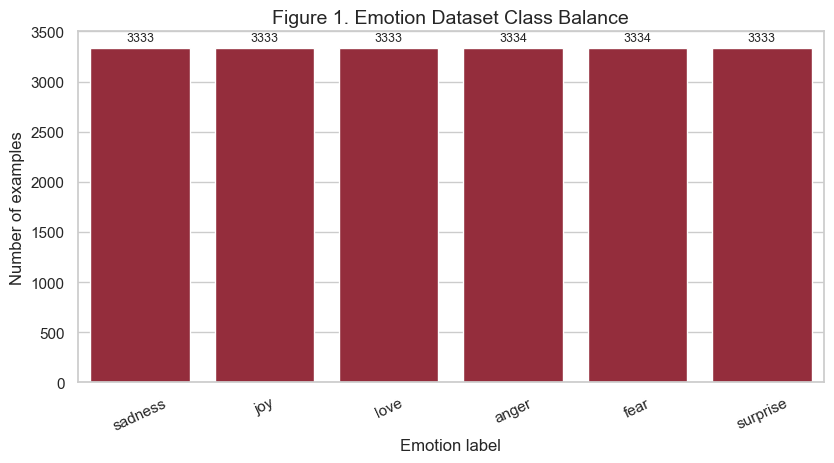


**Interpretation.** The emotion dataset is almost perfectly balanced across its six classes, with counts ranging only from **3,333** to **3,334** examples per label. That makes it a strong source dataset for supervised emotion learning because later models will not be dominated by one emotion class.


In [ ]:
emotion_counts = emotion["label_name"].value_counts().reindex(EMOTION_ORDER)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.barplot(
    x=emotion_counts.index,
    y=emotion_counts.values,
    color="#A51C30",
    ax=ax,
)
ax.set_title("Figure 1. Emotion Dataset Class Balance", fontsize=14)
ax.set_xlabel("Emotion label")
ax.set_ylabel("Number of examples")
ax.tick_params(axis="x", rotation=25)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "ms2_emotion_class_balance.png", dpi=200, bbox_inches="tight")
plt.show()

display(
    Markdown(
        f"""
**Interpretation.** The emotion dataset is almost perfectly balanced across its six classes, with counts ranging only from **{emotion_counts.min():,}** to **{emotion_counts.max():,}** examples per label. That makes it a strong source dataset for supervised emotion learning because later models will not be dominated by one emotion class.
"""
    )
)

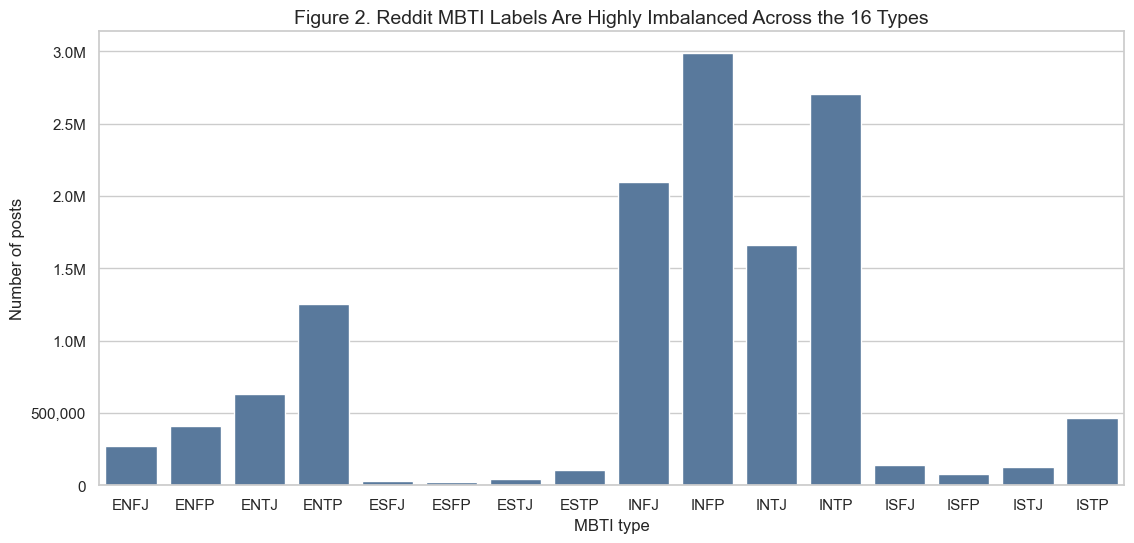


**Interpretation.** The MBTI dataset is extremely skewed: **INFP** alone accounts for **22.94%** of all posts, while **ESFP** contributes only **0.18%**. This argues against treating the 16-way type prediction problem as a balanced classification task without reweighting, resampling, or a shift to the four binary MBTI dimensions.


In [ ]:
type_share = (type_counts / len(reddit) * 100).round(2)

fig, ax = plt.subplots(figsize=(11.5, 5.6))
sns.barplot(
    x=type_counts.index,
    y=type_counts.values,
    color="#4E79A7",
    ax=ax,
)
ax.set_title("Figure 2. Reddit MBTI Labels Are Highly Imbalanced Across the 16 Types", fontsize=14)
ax.set_xlabel("MBTI type")
ax.set_ylabel("Number of posts")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: million_label(x)))
fig.tight_layout()
fig.savefig(FIG_DIR / "ms2_mbti_type_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

display(
    Markdown(
        f"""
**Interpretation.** The MBTI dataset is extremely skewed: **{type_counts.index[0]}** alone accounts for **{type_share.iloc[0]:.2f}%** of all posts, while **{type_counts.index[-1]}** contributes only **{type_share.iloc[-1]:.2f}%**. This argues against treating the 16-way type prediction problem as a balanced classification task without reweighting, resampling, or a shift to the four binary MBTI dimensions.
"""
    )
)

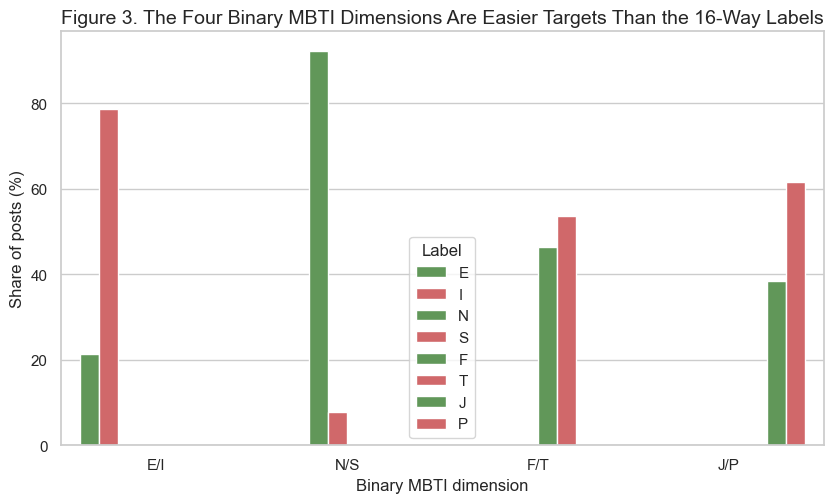


**Interpretation.** The binary MBTI dimensions are still imbalanced, but they are noticeably more manageable than the full 16-type label space. The strongest skew is **N/S**, where **N** makes up **92.23%** of posts, while **F/T** is much closer to balanced with only a **7.22** percentage-point gap. This suggests that later binary modeling should be easier than 16-way type prediction, especially for `F/T`.


In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
sns.barplot(
    data=dimension_share,
    x="dimension",
    y="share_pct",
    hue="label",
    palette=["#59A14F", "#E15759"],
    ax=ax,
)
ax.set_title("Figure 3. The Four Binary MBTI Dimensions Are Easier Targets Than the 16-Way Labels", fontsize=14)
ax.set_xlabel("Binary MBTI dimension")
ax.set_ylabel("Share of posts (%)")
ax.legend(title="Label", frameon=True)
fig.tight_layout()
fig.savefig(FIG_DIR / "ms2_mbti_dimension_balance.png", dpi=200, bbox_inches="tight")
plt.show()

ns_share = dimension_share.query("dimension == 'N/S' and label == 'N'")["share_pct"].iloc[0]
ft_gap = abs(
    dimension_share.query("dimension == 'F/T' and label == 'F'")["share_pct"].iloc[0]
    - dimension_share.query("dimension == 'F/T' and label == 'T'")["share_pct"].iloc[0]
)

display(
    Markdown(
        f"""
**Interpretation.** The binary MBTI dimensions are still imbalanced, but they are noticeably more manageable than the full 16-type label space. The strongest skew is **N/S**, where **N** makes up **{ns_share:.2f}%** of posts, while **F/T** is much closer to balanced with only a **{ft_gap:.2f}** percentage-point gap. This suggests that later binary modeling should be easier than 16-way type prediction, especially for `F/T`.
"""
    )
)

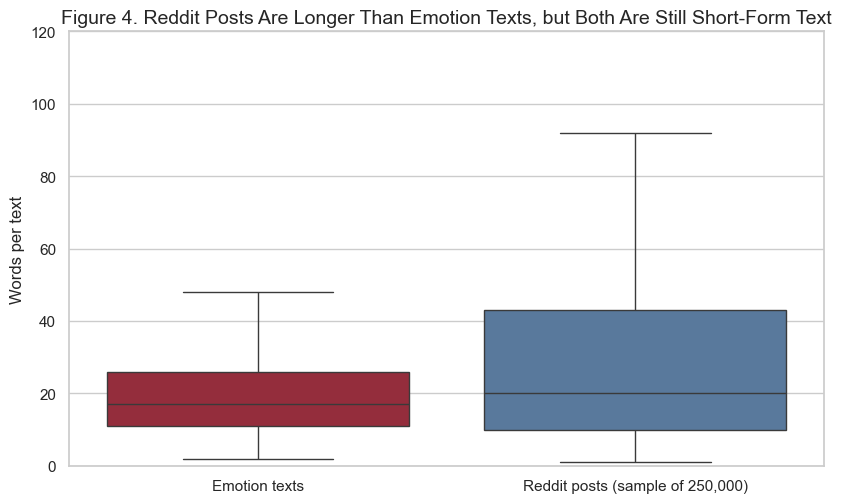


**Interpretation.** The median Reddit post in the fixed sample has **20** words, compared with **17** words in the emotion dataset. Reddit posts are more variable and have a heavier tail, but both datasets are still short-form social text rather than long documents. That makes transfer learning from the emotion data conceptually reasonable, while still requiring some care around Reddit's longer tail.


In [ ]:
length_df = pd.concat(
    [
        emotion[["word_count"]].assign(dataset="Emotion texts"),
        reddit_sample[["word_count"]].assign(dataset=f"Reddit posts (sample of {reddit_sample_n:,})"),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
sns.boxplot(
    data=length_df,
    x="dataset",
    y="word_count",
    showfliers=False,
    palette=["#A51C30", "#4E79A7"],
    ax=ax,
)
ax.set_title("Figure 4. Reddit Posts Are Longer Than Emotion Texts, but Both Are Still Short-Form Text", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("Words per text")
ax.set_ylim(0, 120)
fig.tight_layout()
fig.savefig(FIG_DIR / "ms2_length_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

display(
    Markdown(
        f"""
**Interpretation.** The median Reddit post in the fixed sample has **{int(reddit_sample['word_count'].median()):,}** words, compared with **{int(emotion['word_count'].median()):,}** words in the emotion dataset. Reddit posts are more variable and have a heavier tail, but both datasets are still short-form social text rather than long documents. That makes transfer learning from the emotion data conceptually reasonable, while still requiring some care around Reddit's longer tail.
"""
    )
)

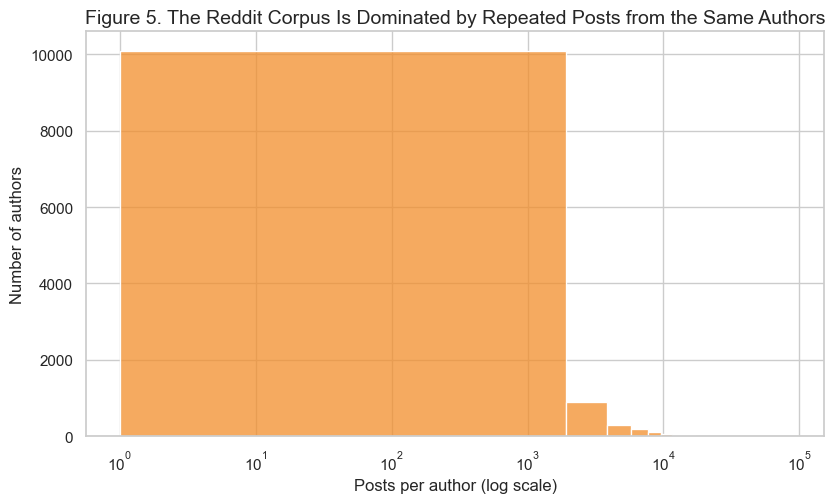


**Interpretation.** The median author contributes **272** posts, the 99th percentile contributes **12,753**, and the top 1% of authors contribute **18.98%** of all posts. This is a major modeling implication: future train/test splits must be done at the **author level**, not the post level, or the model will leak author-specific writing style across splits.


In [ ]:
top_one_percent_n = max(1, round(len(author_post_counts) * 0.01))
top_one_percent_share = author_post_counts.sort_values(ascending=False).head(top_one_percent_n).sum() / len(reddit) * 100

fig, ax = plt.subplots(figsize=(8.5, 5.2))
sns.histplot(author_post_counts, bins=45, color="#F28E2B", ax=ax)
ax.set_xscale("log")
ax.set_title("Figure 5. The Reddit Corpus Is Dominated by Repeated Posts from the Same Authors", fontsize=14)
ax.set_xlabel("Posts per author (log scale)")
ax.set_ylabel("Number of authors")
fig.tight_layout()
fig.savefig(FIG_DIR / "ms2_posts_per_author.png", dpi=200, bbox_inches="tight")
plt.show()

display(
    Markdown(
        f"""
**Interpretation.** The median author contributes **{int(author_post_counts.median()):,}** posts, the 99th percentile contributes **{int(author_post_counts.quantile(0.99)):,}**, and the top 1% of authors contribute **{top_one_percent_share:.2f}%** of all posts. This is a major modeling implication: future train/test splits must be done at the **author level**, not the post level, or the model will leak author-specific writing style across splits.
"""
    )
)

## 5. Data Analysis, Confounders, and Meaningful Insights

The tables and figures above suggest several patterns that matter directly for the project question.

### Patterns, trends, and outliers

- The emotion dataset is balanced and compact, so it is well suited for building an initial emotion signal without heavy class rebalancing.
- The Reddit dataset is very large but highly imbalanced across the 16 MBTI types, with especially strong skew toward intuitive (`N`) and introverted (`I`) labels.
- Reddit text is longer and more variable than the emotion text, but it still falls in the short-form social-text regime.
- Author contribution is extremely uneven, with a long tail of prolific authors creating a clear risk of leakage if posts are split naively.

### Potential confounding or unmeasured variables

- MBTI labels are self-reported, so label noise is likely.
- The Reddit dataset does not include subreddit, topic, or timestamp metadata in the analysis file, so topic effects and time effects cannot be controlled here.
- Because some authors write far more than others, apparent personality patterns may partly reflect prolific-user behavior instead of broad population-level trends.
- The two datasets come from different platforms, so domain mismatch is still present even though both are short-form text.

### Meaningful insights for later modeling

1. **Use author-level splits.** The same labeled author appears many times, so row-level train/test splitting would overstate performance.
2. **Prefer binary MBTI dimensions over a 16-way type model as an early baseline.** The 16-type distribution is too skewed, while some binary dimensions, especially `F/T`, are much closer to balanced.
3. **Treat the emotion dataset as a source of transferable supervision, not a perfect domain match.** The text lengths are compatible enough to justify transfer, but Reddit's heavier tail means later models should be robust to longer posts.
4. **Additional metadata could strengthen the project later.** If we need better controls, subreddit or topic metadata would help separate personality-related language from subject-matter differences.

## 6. Summary of Findings

- The notebook successfully accesses both datasets locally: a **2.35 MB** balanced emotion dataset and a **2.70 GB** Reddit MBTI dataset.
- The emotion dataset is clean, balanced, and immediately usable for supervised emotion learning.
- The Reddit MBTI dataset is usable after very light cleaning, but it is **highly imbalanced** across the 16 types and is structured as **many posts from a relatively small set of repeated authors**.
- Later modeling should therefore use **author-level evaluation**, consider **binary MBTI dimensions** before 16-way classification, and account for the fact that Reddit posts are somewhat longer and more variable than the emotion texts.



## 7. Rescope and Revised Research Question

Our initial idea was to predict MBTI type directly from Reddit posts. After EDA, we found that this was not a strong problem setup for this dataset. The 16 MBTI types are highly imbalanced, the labels are self reported, and many posts come from the same authors. These properties make direct post level 16 class prediction difficult and unreliable.

We therefore revise the project in two ways. First, we focus on the four MBTI dimensions E or I, N or S, F or T, and J or P, instead of all 16 types. Second, we move from post level prediction to user level prediction by combining information across posts from the same author.

Our revised research question is:

**Can a transformer trained for emotion classification learn features that help predict the four MBTI dimensions at the user level from Reddit text?**

This revised question is a better fit for both the data and the course. It keeps a clear deep learning component through transformer based emotion modeling, and it also gives us a cleaner and more realistic prediction task.